In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass
from pathlib import Path
from urllib.parse import urlparse

import boto3
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.fs as pafs

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")


In [2]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

DATA_URI = "s3://pdga-bronze-266672886271-us-east-2/gold/pdga/wind_effects/model_inputs_hole/"
AWS_REGION = "us-east-2"

SPLIT_SEED = 11
TEST_SIZE = 0.20
KEEP_ONLY_WEATHER_READY_ROWS = True

OUTPUT_DIR = Path.cwd() / "notebook_exports"
OUTPUT_DIR.mkdir(exist_ok=True)

CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1200,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_seed": 42,
    "verbose": 100,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}


In [3]:
# -----------------------------------------------------------------------------
# Load helpers
# -----------------------------------------------------------------------------

def get_s3_bucket_region(bucket: str, default_region: str = "us-east-1") -> str:
    s3 = boto3.client("s3", region_name=default_region)
    resp = s3.get_bucket_location(Bucket=bucket)
    region = resp.get("LocationConstraint")
    return "us-east-1" if region is None else region


def build_hole_input_schema() -> pa.Schema:
    return pa.schema(
        [
            pa.field("event_year", pa.int64()),
            pa.field("tourn_id", pa.int64()),
            pa.field("round_number", pa.int64()),
            pa.field("hole_number", pa.int64()),
            pa.field("player_key", pa.string()),
            pa.field("player_rating", pa.int64()),
            pa.field("course_id", pa.int64()),
            pa.field("hole_length", pa.float64()),
            pa.field("hole_par", pa.int64()),
            pa.field("hole_score", pa.int64()),
            pa.field("actual_strokes", pa.int64()),
            pa.field("hole_to_par", pa.int64()),
            pa.field("strokes_over_par", pa.int64()),
            pa.field("target_strokes_over_par", pa.int64()),
            pa.field("division", pa.string()),
            pa.field("weather_available_flag", pa.bool_()),
            pa.field("wx_weather_missing_flag", pa.bool_()),
            pa.field("wx_wind_speed_mps", pa.float64()),
            pa.field("wx_wind_gust_mps", pa.float64()),
            pa.field("wx_wind_dir_deg", pa.float64()),
            pa.field("wx_temperature_c", pa.float64()),
            pa.field("wx_precip_mm", pa.float64()),
            pa.field("wx_pressure_hpa", pa.float64()),
            pa.field("wx_relative_humidity_pct", pa.float64()),
            pa.field("feature_wind_speed_mps", pa.float64()),
            pa.field("feature_wind_gust_mps", pa.float64()),
            pa.field("feature_wind_dir_deg", pa.float64()),
            pa.field("feature_temp_c", pa.float64()),
            pa.field("feature_precip_mm", pa.float64()),
            pa.field("feature_pressure_hpa", pa.float64()),
            pa.field("feature_humidity_pct", pa.float64()),
            pa.field("wind_speed_bucket", pa.string()),
            pa.field("layout_id", pa.int64()),
            pa.field("feature_layout_id", pa.int64()),
            pa.field("feature_course_id", pa.int64()),
            pa.field("source_content_sha256", pa.string()),
            pa.field("row_hash_sha256", pa.string()),
        ]
    )


def _build_arrow_dataset(uri: str, aws_region: str = "us-east-1") -> ds.Dataset:
    schema = build_hole_input_schema()

    if uri.startswith("s3://"):
        parsed = urlparse(uri)
        bucket = parsed.netloc
        key = parsed.path.lstrip("/").rstrip("/")
        fs = pafs.S3FileSystem(region=get_s3_bucket_region(bucket, aws_region))
        return ds.dataset(
            f"{bucket}/{key}",
            filesystem=fs,
            format="parquet",
            partitioning="hive",
            schema=schema,
        )

    path = Path(uri)
    if not path.exists():
        raise FileNotFoundError(uri)

    return ds.dataset(str(path), format="parquet", partitioning="hive", schema=schema)


def load_partitioned_parquet(uri: str, aws_region: str = "us-east-1") -> pd.DataFrame:
    return _build_arrow_dataset(uri, aws_region).to_table().to_pandas()


In [4]:
# -----------------------------------------------------------------------------
# Canonicalization
# -----------------------------------------------------------------------------

def first_present(df: pd.DataFrame, candidates: list[str], required: bool = False) -> pd.Series:
    for col in candidates:
        if col in df.columns:
            return df[col]
    if required:
        raise KeyError(f"Missing required column. Tried: {candidates}")
    return pd.Series(pd.NA, index=df.index)


def canonicalize_hole_model_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=raw_df.index)

    out["event_year"] = first_present(raw_df, ["event_year"])
    out["tourn_id"] = first_present(raw_df, ["tourn_id", "event_id"], required=True)
    out["round_number"] = first_present(raw_df, ["round_number"], required=True)
    out["hole_number"] = first_present(raw_df, ["hole_number"], required=True)
    out["player_key"] = first_present(raw_df, ["player_key"], required=True)

    out["actual_strokes"] = first_present(raw_df, ["actual_strokes", "hole_score"], required=True)
    out["player_rating"] = first_present(raw_df, ["player_rating"], required=True)
    out["course_id"] = first_present(raw_df, ["course_id", "feature_course_id"], required=True)
    out["hole_length"] = first_present(raw_df, ["hole_length"], required=True)
    out["hole_par"] = first_present(raw_df, ["hole_par"], required=True)
    out["division"] = first_present(raw_df, ["division"], required=False)
    out["weather_available_flag"] = first_present(raw_df, ["weather_available_flag"], required=False)

    for col in [
        "event_year", "tourn_id", "round_number", "hole_number",
        "actual_strokes", "player_rating", "course_id", "hole_length", "hole_par",
    ]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["player_key"] = out["player_key"].astype("string")
    out["division"] = out["division"].astype("string")
    out["weather_available_flag"] = out["weather_available_flag"].astype("boolean")

    return out


raw_df = load_partitioned_parquet(DATA_URI, aws_region=AWS_REGION)
model_df = canonicalize_hole_model_frame(raw_df)

if KEEP_ONLY_WEATHER_READY_ROWS and model_df["weather_available_flag"].notna().any():
    model_df = model_df[model_df["weather_available_flag"] == True].copy()

model_df = model_df.dropna(
    subset=[
        "event_year", "tourn_id", "round_number", "hole_number", "player_key",
        "actual_strokes", "player_rating", "course_id", "hole_length", "hole_par",
    ]
).copy()

model_df = model_df[model_df["actual_strokes"].between(1, 15)].copy()
model_df = model_df[model_df["hole_par"].between(2, 6)].copy()
model_df = model_df[model_df["hole_length"].between(30, 2000)].copy()
model_df = model_df[model_df["player_rating"].between(500, 1100)].copy()

model_df["course_id"] = model_df["course_id"].astype("Int64").astype("string")
model_df["hole_par"] = model_df["hole_par"].astype("Int64").astype("string")
model_df["division"] = model_df["division"].astype("string")

print(model_df.shape)
model_df.head()


(7747821, 12)


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,player_rating,course_id,hole_length,hole_par,division,weather_available_flag
0,2025,90000,1,1,PDGA#112424,3,935.0,25925,274.0,3,MA50,True
2,2025,90000,1,1,PDGA#119010,3,951.0,25925,274.0,3,MPO,True
3,2025,90000,1,1,PDGA#138418,3,922.0,25925,274.0,3,MA1,True
4,2025,90000,1,1,PDGA#176385,4,875.0,25925,274.0,3,MA3,True
7,2025,90000,1,1,PDGA#208208,5,771.0,25925,274.0,3,MJ15,True


In [5]:
# -----------------------------------------------------------------------------
# Feature engineering
# -----------------------------------------------------------------------------

feature_df = model_df.copy()

feature_df["round_number_cat"] = feature_df["round_number"].astype("Int64").astype("string")
feature_df["hole_length_over_par"] = feature_df["hole_length"] / feature_df["hole_par"].astype(float)
feature_df["hole_length_times_par"] = feature_df["hole_length"] * feature_df["hole_par"].astype(float)

feature_df["player_rating_centered"] = feature_df["player_rating"] - feature_df["player_rating"].mean()
feature_df["player_rating_sq"] = feature_df["player_rating"] ** 2

feature_df["is_par_3"] = (feature_df["hole_par"] == "3").astype(int)
feature_df["is_par_4"] = (feature_df["hole_par"] == "4").astype(int)
feature_df["is_par_5"] = (feature_df["hole_par"] == "5").astype(int)

feature_df["is_long_hole"] = (feature_df["hole_length"] >= feature_df["hole_length"].median()).astype(int)
feature_df["is_high_rating_player"] = (feature_df["player_rating"] >= feature_df["player_rating"].median()).astype(int)

feature_df.head()


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,player_rating,course_id,hole_length,hole_par,division,weather_available_flag,round_number_cat,hole_length_over_par,hole_length_times_par,player_rating_centered,player_rating_sq,is_par_3,is_par_4,is_par_5,is_long_hole,is_high_rating_player
0,2025,90000,1,1,PDGA#112424,3,935.0,25925,274.0,3,MA50,True,1,91.333333,822.0,46.173286,874225.0,1,0,0,1,1
2,2025,90000,1,1,PDGA#119010,3,951.0,25925,274.0,3,MPO,True,1,91.333333,822.0,62.173286,904401.0,1,0,0,1,1
3,2025,90000,1,1,PDGA#138418,3,922.0,25925,274.0,3,MA1,True,1,91.333333,822.0,33.173286,850084.0,1,0,0,1,1
4,2025,90000,1,1,PDGA#176385,4,875.0,25925,274.0,3,MA3,True,1,91.333333,822.0,-13.826714,765625.0,1,0,0,1,0
7,2025,90000,1,1,PDGA#208208,5,771.0,25925,274.0,3,MJ15,True,1,91.333333,822.0,-117.826714,594441.0,1,0,0,1,0


In [6]:
# -----------------------------------------------------------------------------
# Held-out-by-event split
# -----------------------------------------------------------------------------

def event_split(df: pd.DataFrame, seed: int, test_size: float = 0.20) -> tuple[pd.DataFrame, pd.DataFrame]:
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    groups = df["tourn_id"].astype(int)
    train_idx, test_idx = next(splitter.split(df, groups=groups))

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    train_events = set(train_df["tourn_id"].astype(int).unique())
    test_events = set(test_df["tourn_id"].astype(int).unique())
    assert train_events.isdisjoint(test_events)

    return train_df, test_df


train_df, test_df = event_split(feature_df, seed=SPLIT_SEED, test_size=TEST_SIZE)
print(train_df.shape, test_df.shape)


(6183077, 22) (1564744, 22)


In [7]:
# -----------------------------------------------------------------------------
# Experiment definitions
# -----------------------------------------------------------------------------

EXPERIMENTS = [
    {
        "name": "base",
        "numeric": ["player_rating", "hole_length"],
        "categorical": ["hole_par", "course_id", "division"],
    },
    {
        "name": "base_plus_round",
        "numeric": ["player_rating", "hole_length"],
        "categorical": ["hole_par", "course_id", "division", "round_number_cat"],
    },
    {
        "name": "base_plus_engineered_hole",
        "numeric": ["player_rating", "hole_length", "hole_length_over_par", "hole_length_times_par"],
        "categorical": ["hole_par", "course_id", "division"],
    },
    {
        "name": "base_plus_round_plus_engineered_hole",
        "numeric": ["player_rating", "hole_length", "hole_length_over_par", "hole_length_times_par"],
        "categorical": ["hole_par", "course_id", "division", "round_number_cat"],
    },
    {
        "name": "base_no_division",
        "numeric": ["player_rating", "hole_length"],
        "categorical": ["hole_par", "course_id"],
    },
    {
        "name": "base_plus_rating_transforms",
        "numeric": ["player_rating", "hole_length", "player_rating_centered", "player_rating_sq"],
        "categorical": ["hole_par", "course_id", "division"],
    },
    {
        "name": "base_plus_flags",
        "numeric": ["player_rating", "hole_length", "is_par_3", "is_par_4", "is_par_5", "is_long_hole", "is_high_rating_player"],
        "categorical": ["hole_par", "course_id", "division"],
    },
]


In [8]:
# -----------------------------------------------------------------------------
# Train/evaluate helper
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def summarize_residuals_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return (
        df.groupby(group_col, dropna=False, as_index=False)
        .agg(
            rows=("actual_strokes", "size"),
            residual_mean=("residual_strokes", "mean"),
            residual_std=("residual_strokes", "std"),
            mae=("abs_residual_strokes", "mean"),
        )
    )


def train_catboost_experiment(train_df: pd.DataFrame, test_df: pd.DataFrame, experiment: dict) -> tuple[pd.DataFrame, dict]:
    numeric_cols = [c for c in experiment["numeric"] if c in train_df.columns]
    categorical_cols = [c for c in experiment["categorical"] if c in train_df.columns and train_df[c].notna().any()]
    feature_cols = numeric_cols + categorical_cols

    fit_train = train_df.copy()
    fit_test = test_df.copy()

    for col in numeric_cols + ["actual_strokes"]:
        fit_train[col] = pd.to_numeric(fit_train[col], errors="coerce")
        fit_test[col] = pd.to_numeric(fit_test[col], errors="coerce")

    fit_train = fit_train.dropna(subset=numeric_cols + ["actual_strokes"]).copy()
    fit_test = fit_test.dropna(subset=numeric_cols + ["actual_strokes"]).copy()

    for col in categorical_cols:
        fit_train[col] = fit_train[col].astype("string").fillna("__MISSING__").astype(str)
        fit_test[col] = fit_test[col].astype("string").fillna("__MISSING__").astype(str)

        train_levels = set(fit_train[col].unique())
        fit_test[col] = fit_test[col].where(fit_test[col].isin(train_levels), "__MISSING__")

    cat_idx = [feature_cols.index(c) for c in categorical_cols]

    train_pool = Pool(fit_train[feature_cols], label=fit_train["actual_strokes"], cat_features=cat_idx)
    test_pool = Pool(fit_test[feature_cols], label=fit_test["actual_strokes"], cat_features=cat_idx)

    model = CatBoostRegressor(**CATBOOST_PARAMS)

    start = time.perf_counter()
    model.fit(
        train_pool,
        eval_set=test_pool,
        use_best_model=True,
        early_stopping_rounds=100,
    )
    pred = model.predict(test_pool)
    runtime_sec = time.perf_counter() - start

    scored = fit_test[
        [
            "tourn_id", "round_number", "hole_number", "player_key",
            "actual_strokes", "player_rating", "course_id", "hole_length", "hole_par", "division"
        ]
    ].copy()

    scored["expected_strokes"] = pred
    scored["residual_strokes"] = scored["actual_strokes"] - scored["expected_strokes"]
    scored["abs_residual_strokes"] = scored["residual_strokes"].abs()

    metrics = regression_metrics(scored["actual_strokes"], scored["expected_strokes"])
    metrics["runtime_sec"] = runtime_sec
    metrics["best_iteration"] = getattr(model, "best_iteration_", None)
    metrics["feature_count"] = len(feature_cols)
    metrics["categorical_feature_count"] = len(categorical_cols)

    for group_col in ["division", "hole_par"]:
        group_df = summarize_residuals_by_group(scored[scored[group_col].notna()].copy(), group_col)
        metrics[f"{group_col}_max_abs_residual_mean"] = float(group_df["residual_mean"].abs().max()) if len(group_df) else np.nan

    scored["hole_length_bin"] = pd.qcut(scored["hole_length"], q=10, duplicates="drop")
    scored["player_rating_bin"] = pd.qcut(scored["player_rating"], q=10, duplicates="drop")

    hole_len_bias = summarize_residuals_by_group(scored, "hole_length_bin")
    rating_bias = summarize_residuals_by_group(scored, "player_rating_bin")

    metrics["hole_length_bin_max_abs_residual_mean"] = float(hole_len_bias["residual_mean"].abs().max()) if len(hole_len_bias) else np.nan
    metrics["player_rating_bin_max_abs_residual_mean"] = float(rating_bias["residual_mean"].abs().max()) if len(rating_bias) else np.nan

    return scored, metrics


In [9]:
# -----------------------------------------------------------------------------
# Run experiments
# -----------------------------------------------------------------------------

results = []
scored_outputs = {}

for experiment in EXPERIMENTS:
    print(f"Running experiment: {experiment['name']}")
    scored_df, metrics = train_catboost_experiment(train_df, test_df, experiment)
    metrics["experiment"] = experiment["name"]
    results.append(metrics)
    scored_outputs[experiment["name"]] = scored_df

experiment_results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["rmse", "mae", "player_rating_bin_max_abs_residual_mean", "hole_length_bin_max_abs_residual_mean"],
        ascending=[True, True, True, True],
    )
    .reset_index(drop=True)
)

experiment_results_df


Running experiment: base
0:	learn: 1.0153851	test: 1.0156905	best: 1.0156905 (0)	total: 2.38s	remaining: 47m 33s
100:	learn: 0.7938949	test: 0.7997817	best: 0.7997817 (100)	total: 2m 3s	remaining: 22m 27s
200:	learn: 0.7903551	test: 0.7965598	best: 0.7965598 (200)	total: 4m 14s	remaining: 21m 3s
300:	learn: 0.7891387	test: 0.7956443	best: 0.7956443 (300)	total: 7m 5s	remaining: 21m 11s
400:	learn: 0.7885318	test: 0.7953756	best: 0.7953756 (400)	total: 9m 35s	remaining: 19m 6s
500:	learn: 0.7881498	test: 0.7953029	best: 0.7953027 (497)	total: 12m 4s	remaining: 16m 51s
600:	learn: 0.7878696	test: 0.7950747	best: 0.7950747 (600)	total: 14m 17s	remaining: 14m 14s
700:	learn: 0.7876350	test: 0.7950137	best: 0.7949583 (681)	total: 16m 35s	remaining: 11m 48s
800:	learn: 0.7874334	test: 0.7947997	best: 0.7947997 (800)	total: 18m 40s	remaining: 9m 18s
900:	learn: 0.7872624	test: 0.7946927	best: 0.7946927 (900)	total: 21m 14s	remaining: 7m 2s
1000:	learn: 0.7871158	test: 0.7946684	best: 0.794668

,mae,rmse,r2,runtime_sec,best_iteration,feature_count,categorical_feature_count,division_max_abs_residual_mean,hole_par_max_abs_residual_mean,hole_length_bin_max_abs_residual_mean,player_rating_bin_max_abs_residual_mean,experiment
0,0.588675,0.794202,0.410217,1578.513390,1136,7,3,0.464723,0.224672,0.034947,0.018254,base_plus_engineered_hole
1,0.588535,0.794238,0.410164,1268.725063,955,8,4,0.429415,0.304528,0.045777,0.023292,base_plus_round_plus_engineered_hole
2,0.588827,0.794503,0.409771,1015.456783,542,6,4,0.410499,0.408865,0.041325,0.019429,base_plus_round
3,0.589087,0.794582,0.409653,1658.666554,1193,5,3,0.406593,0.589979,0.031708,0.019276,base
4,0.588925,0.794845,0.409261,1474.537205,1194,7,3,0.424669,0.559758,0.034562,0.020547,base_plus_rating_transforms
5,0.589197,0.794924,0.409144,894.616932,600,10,3,0.416530,0.403326,0.037232,0.018131,base_plus_flags
6,0.588985,0.795351,0.408510,1136.119443,958,4,2,0.431517,0.483495,0.040957,0.022617,base_no_division


In [10]:
# -----------------------------------------------------------------------------
# Select winner
# -----------------------------------------------------------------------------

best_experiment = experiment_results_df.iloc[0]["experiment"]
print("Best experiment:", best_experiment)

best_scored_df = scored_outputs[best_experiment].copy()
best_scored_df.head()


Best experiment: base_plus_engineered_hole


,tourn_id,round_number,hole_number,player_key,actual_strokes,player_rating,course_id,hole_length,hole_par,division,expected_strokes,residual_strokes,abs_residual_strokes,hole_length_bin,player_rating_bin
324,90001,1,1,PDGA#108871,4,911.0,241646,515.0,4,FPO,4.286682,-0.286682,0.286682,"(463.0, 1251.0]","(910.0, 924.0]"
325,90001,1,1,PDGA#121690,3,997.0,241646,515.0,4,MPO,3.673216,-0.673216,0.673216,"(463.0, 1251.0]","(961.0, 1059.0]"
326,90001,1,1,PDGA#126698,4,930.0,241646,515.0,4,MA40,4.110400,-0.110400,0.110400,"(463.0, 1251.0]","(924.0, 940.0]"
327,90001,1,1,PDGA#127239,4,922.0,241646,515.0,4,MA2,4.128976,-0.128976,0.128976,"(463.0, 1251.0]","(910.0, 924.0]"
328,90001,1,1,PDGA#132233,5,955.0,241646,515.0,4,MPO,3.972136,1.027864,1.027864,"(463.0, 1251.0]","(940.0, 961.0]"


In [11]:
# -----------------------------------------------------------------------------
# Compare key residual-bias tables for winner
# -----------------------------------------------------------------------------

best_scored_df["hole_length_bin"] = pd.qcut(best_scored_df["hole_length"], q=10, duplicates="drop")
best_scored_df["player_rating_bin"] = pd.qcut(best_scored_df["player_rating"], q=10, duplicates="drop")

bias_by_division = summarize_residuals_by_group(best_scored_df[best_scored_df["division"].notna()].copy(), "division")
bias_by_hole_par = summarize_residuals_by_group(best_scored_df, "hole_par")
bias_by_hole_length_bin = summarize_residuals_by_group(best_scored_df, "hole_length_bin")
bias_by_player_rating_bin = summarize_residuals_by_group(best_scored_df, "player_rating_bin")

bias_by_division, bias_by_hole_par, bias_by_hole_length_bin, bias_by_player_rating_bin


(   division    rows  residual_mean  residual_std       mae
 0       FA1   18241       0.006483      0.834132  0.632997
 1       FA2   13906      -0.012421      0.852330  0.653268
 2       FA3   14468       0.011692      0.899415  0.696923
 3       FA4    7021       0.051882      0.931828  0.709842
 4      FA40    6874       0.058114      0.823642  0.623325
 5      FA50    6097       0.056900      0.839839  0.635700
 6      FA55     295      -0.128789      0.811679  0.649282
 7      FA60    2815      -0.033632      0.851551  0.622555
 8      FA65      62      -0.206940      0.828664  0.682241
 9      FA70     126       0.279678      0.745670  0.627503
 10     FA80      74      -0.123852      0.621117  0.510971
 11      FC1     684       0.052215      0.957774  0.728479
 12     FJ08      36       0.281913      1.028314  0.745645
 13     FJ10      72      -0.226517      1.141502  0.835655
 14     FJ12     324      -0.084337      0.959973  0.731109
 15     FJ15     692       0.150953     

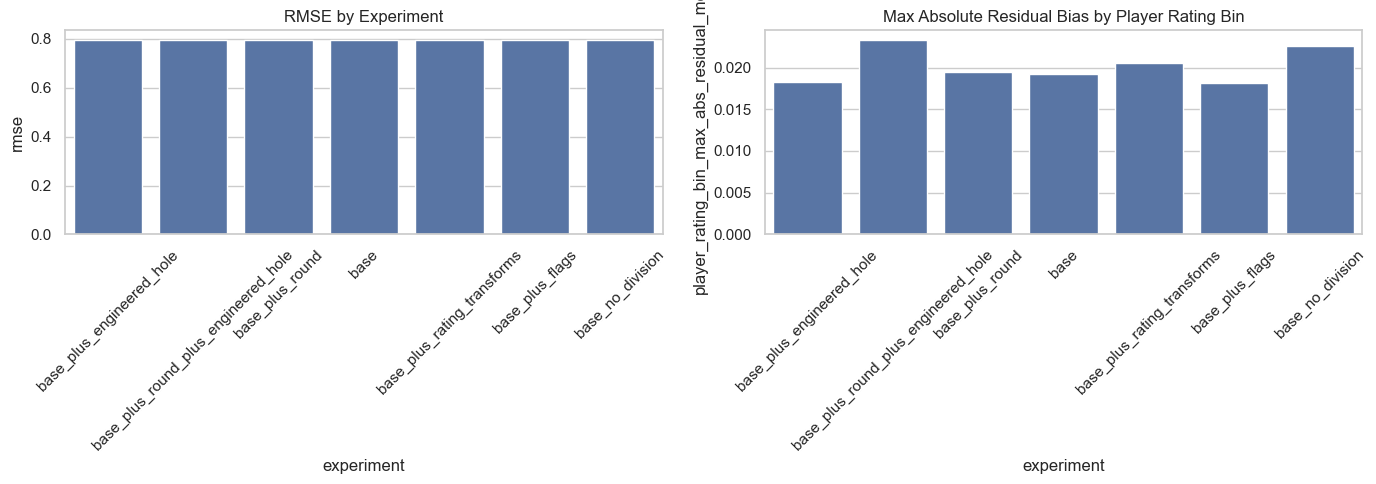

In [12]:
# -----------------------------------------------------------------------------
# Quick chart for experiment comparison
# -----------------------------------------------------------------------------

plot_df = experiment_results_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_df, x="experiment", y="rmse", ax=axes[0])
axes[0].set_title("RMSE by Experiment")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=plot_df, x="experiment", y="player_rating_bin_max_abs_residual_mean", ax=axes[1])
axes[1].set_title("Max Absolute Residual Bias by Player Rating Bin")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [13]:
# -----------------------------------------------------------------------------
# Export experiment results
# -----------------------------------------------------------------------------

experiment_results_df.to_csv(OUTPUT_DIR / "catboost_feature_set_experiments_v1.csv", index=False)
print("Wrote:", OUTPUT_DIR / "catboost_feature_set_experiments_v1.csv")


Wrote: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\catboost_feature_set_experiments_v1.csv


In [14]:
# -----------------------------------------------------------------------------
# Residual diagnostics setup for the winning experiment
# -----------------------------------------------------------------------------

winning_df = best_scored_df.copy()

winning_df["abs_residual_strokes"] = winning_df["residual_strokes"].abs()

winning_df["hole_length_bin"] = pd.qcut(
    winning_df["hole_length"],
    q=10,
    duplicates="drop",
)

winning_df["player_rating_bin"] = pd.qcut(
    winning_df["player_rating"],
    q=10,
    duplicates="drop",
)

print("Winning residual frame shape:", winning_df.shape)
winning_df.head()


Winning residual frame shape: (1564744, 15)


,tourn_id,round_number,hole_number,player_key,actual_strokes,player_rating,course_id,hole_length,hole_par,division,expected_strokes,residual_strokes,abs_residual_strokes,hole_length_bin,player_rating_bin
324,90001,1,1,PDGA#108871,4,911.0,241646,515.0,4,FPO,4.286682,-0.286682,0.286682,"(463.0, 1251.0]","(910.0, 924.0]"
325,90001,1,1,PDGA#121690,3,997.0,241646,515.0,4,MPO,3.673216,-0.673216,0.673216,"(463.0, 1251.0]","(961.0, 1059.0]"
326,90001,1,1,PDGA#126698,4,930.0,241646,515.0,4,MA40,4.110400,-0.110400,0.110400,"(463.0, 1251.0]","(924.0, 940.0]"
327,90001,1,1,PDGA#127239,4,922.0,241646,515.0,4,MA2,4.128976,-0.128976,0.128976,"(463.0, 1251.0]","(910.0, 924.0]"
328,90001,1,1,PDGA#132233,5,955.0,241646,515.0,4,MPO,3.972136,1.027864,1.027864,"(463.0, 1251.0]","(940.0, 961.0]"


In [15]:
# -----------------------------------------------------------------------------
# Helper: summarize residuals by group
# -----------------------------------------------------------------------------

def summarize_residuals_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return (
        df.groupby(group_col, dropna=False, as_index=False)
        .agg(
            rows=("actual_strokes", "size"),
            actual_mean=("actual_strokes", "mean"),
            expected_mean=("expected_strokes", "mean"),
            residual_mean=("residual_strokes", "mean"),
            residual_median=("residual_strokes", "median"),
            residual_std=("residual_strokes", "std"),
            mae=("abs_residual_strokes", "mean"),
        )
        .sort_values(["rows", "residual_mean"], ascending=[False, False])
        .reset_index(drop=True)
    )


def interval_sort_key(x):
    if pd.isna(x):
        return (float("inf"), float("inf"))
    return (x.left, x.right)


In [16]:
# -----------------------------------------------------------------------------
# Core residual summary tables
# -----------------------------------------------------------------------------

residuals_by_player_rating_bin = summarize_residuals_by_group(winning_df, "player_rating_bin")
residuals_by_hole_length_bin = summarize_residuals_by_group(winning_df, "hole_length_bin")
residuals_by_hole_par = summarize_residuals_by_group(winning_df, "hole_par")
residuals_by_division = summarize_residuals_by_group(
    winning_df[winning_df["division"].notna()].copy(),
    "division",
)
residuals_by_tourn_id = summarize_residuals_by_group(winning_df, "tourn_id")
residuals_by_course_id = summarize_residuals_by_group(winning_df, "course_id")

residuals_by_player_rating_bin, residuals_by_hole_length_bin, residuals_by_hole_par


(  player_rating_bin    rows  actual_mean  expected_mean  residual_mean  \
 0    (940.0, 961.0]  160085     3.162520       3.161204       0.001316   
 1    (864.0, 881.0]  158783     3.395867       3.393829       0.002038   
 2  (509.999, 806.0]  158569     3.947468       3.929214       0.018254   
 3    (896.0, 910.0]  157990     3.308646       3.300938       0.007708   
 4    (881.0, 896.0]  156786     3.341300       3.331578       0.009721   
 5    (924.0, 940.0]  156679     3.215702       3.210422       0.005280   
 6    (842.0, 864.0]  156472     3.495213       3.482887       0.012326   
 7    (806.0, 842.0]  154534     3.608604       3.595222       0.013382   
 8    (910.0, 924.0]  152680     3.255515       3.243093       0.012422   
 9   (961.0, 1059.0]  152166     3.058752       3.051771       0.006981   
 
    residual_median  residual_std       mae  
 0         0.029629      0.756733  0.562025  
 1        -0.091039      0.790906  0.577767  
 2        -0.139734      0.890712  

In [17]:
# -----------------------------------------------------------------------------
# Common-course view only
# -----------------------------------------------------------------------------
# This helps avoid overreacting to tiny long-tail courses.
# -----------------------------------------------------------------------------

MIN_COURSE_ROWS = 100

residuals_by_course_id_common = residuals_by_course_id[
    residuals_by_course_id["rows"] >= MIN_COURSE_ROWS
].copy()

residuals_by_course_id_common.head(20)


,course_id,rows,actual_mean,expected_mean,residual_mean,residual_median,residual_std,mae
0,__MISSING__,408551,3.427158,3.378963,0.048195,-0.020862,0.811816,0.594609
1,-1,81809,3.593492,3.546625,0.046867,-0.048092,0.838004,0.617526
2,25464,16604,3.260299,3.479477,-0.219178,-0.246819,0.741040,0.591103
3,303364,8614,3.313443,3.227609,0.085834,0.034478,0.755422,0.567830
4,304099,7677,3.102514,3.209373,-0.106859,-0.053254,0.732806,0.552143
5,201017,7671,3.986964,4.154576,-0.167612,-0.274270,0.836803,0.676146
6,26297,7320,3.131694,3.121198,0.010496,-0.034127,0.741484,0.554991
7,27405,6796,3.021336,2.928995,0.092341,0.077463,0.754334,0.557269
8,208216,6771,3.172648,3.218578,-0.045930,-0.056780,0.672643,0.500724
9,24772,6674,2.932274,3.037985,-0.105710,-0.095456,0.619513,0.472634


In [18]:
# -----------------------------------------------------------------------------
# Quick numeric checks for baseline quality
# -----------------------------------------------------------------------------

diagnostic_summary = pd.DataFrame(
    [
        {
            "metric": "overall_residual_mean",
            "value": winning_df["residual_strokes"].mean(),
        },
        {
            "metric": "overall_residual_median",
            "value": winning_df["residual_strokes"].median(),
        },
        {
            "metric": "overall_residual_std",
            "value": winning_df["residual_strokes"].std(),
        },
        {
            "metric": "overall_mae",
            "value": winning_df["abs_residual_strokes"].mean(),
        },
        {
            "metric": "max_abs_player_rating_bin_residual_mean",
            "value": residuals_by_player_rating_bin["residual_mean"].abs().max(),
        },
        {
            "metric": "max_abs_hole_length_bin_residual_mean",
            "value": residuals_by_hole_length_bin["residual_mean"].abs().max(),
        },
        {
            "metric": "max_abs_hole_par_residual_mean",
            "value": residuals_by_hole_par["residual_mean"].abs().max(),
        },
        {
            "metric": "max_abs_division_residual_mean",
            "value": residuals_by_division["residual_mean"].abs().max() if len(residuals_by_division) else np.nan,
        },
        {
            "metric": "max_abs_common_course_residual_mean",
            "value": residuals_by_course_id_common["residual_mean"].abs().max() if len(residuals_by_course_id_common) else np.nan,
        },
    ]
)

diagnostic_summary


,metric,value
0,overall_residual_mean,0.008917
1,overall_residual_median,-0.049249
2,overall_residual_std,0.794152
3,overall_mae,0.588675
4,max_abs_player_rating_bin_residual_mean,0.018254
5,max_abs_hole_length_bin_residual_mean,0.034947
6,max_abs_hole_par_residual_mean,0.224672
7,max_abs_division_residual_mean,0.464723
8,max_abs_common_course_residual_mean,0.660607


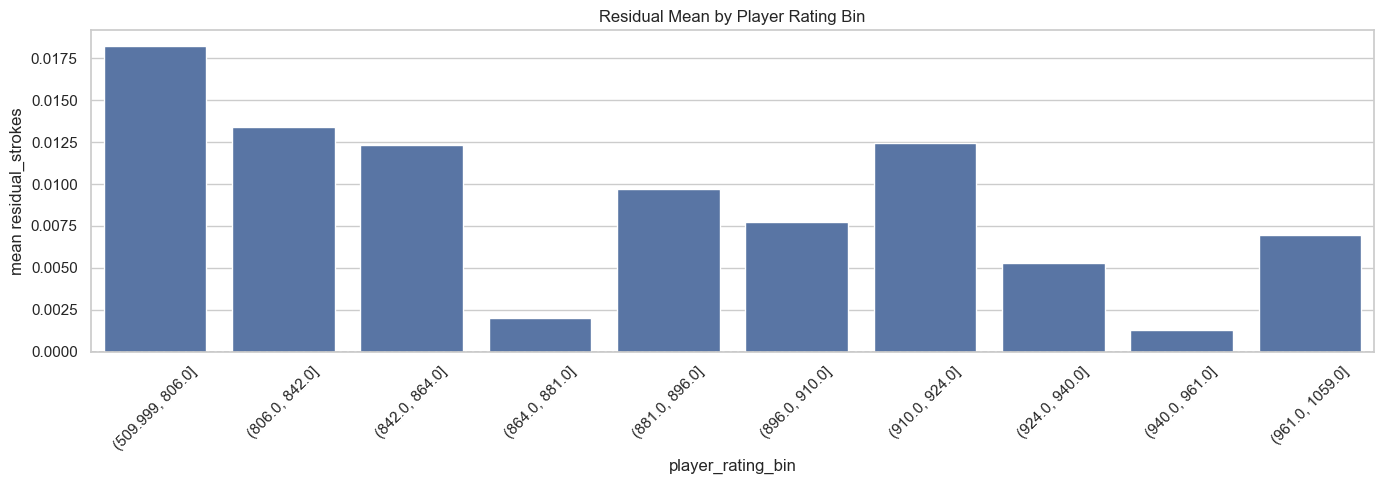

In [19]:
# -----------------------------------------------------------------------------
# Residual mean by player rating bin
# -----------------------------------------------------------------------------

plot_df = residuals_by_player_rating_bin.copy()
bin_order = sorted(
    [x for x in plot_df["player_rating_bin"].dropna().unique()],
    key=interval_sort_key,
)
plot_df["player_rating_bin_str"] = plot_df["player_rating_bin"].astype(str)
bin_order_str = [str(x) for x in bin_order]

plt.figure(figsize=(14, 5))
sns.barplot(
    data=plot_df,
    x="player_rating_bin_str",
    y="residual_mean",
    order=bin_order_str,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Player Rating Bin")
plt.xlabel("player_rating_bin")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


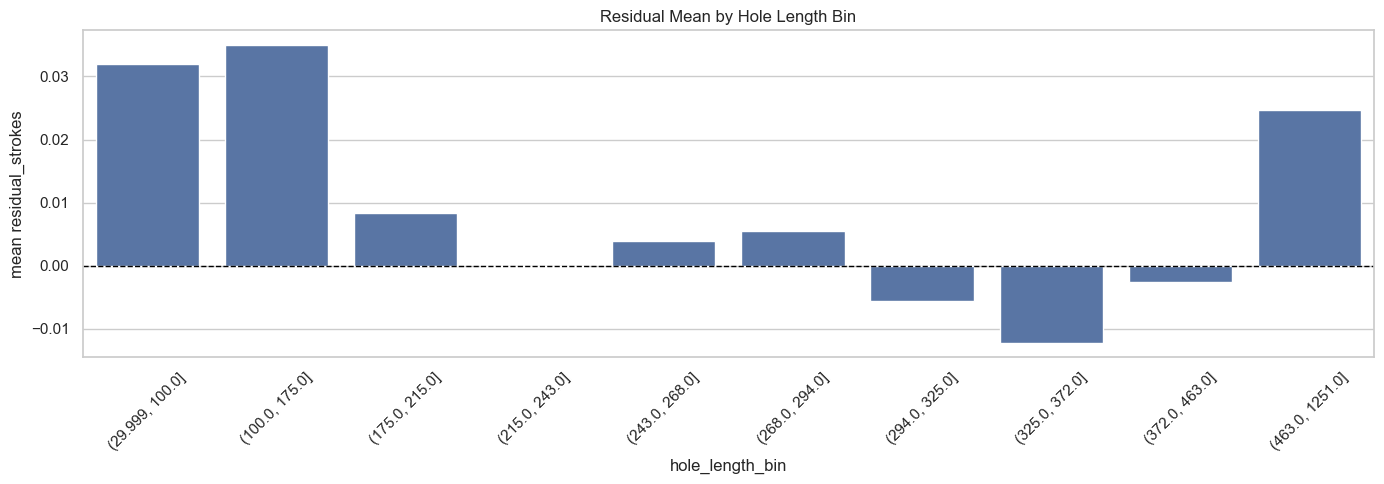

In [20]:
# -----------------------------------------------------------------------------
# Residual mean by hole length bin
# -----------------------------------------------------------------------------

plot_df = residuals_by_hole_length_bin.copy()
bin_order = sorted(
    [x for x in plot_df["hole_length_bin"].dropna().unique()],
    key=interval_sort_key,
)
plot_df["hole_length_bin_str"] = plot_df["hole_length_bin"].astype(str)
bin_order_str = [str(x) for x in bin_order]

plt.figure(figsize=(14, 5))
sns.barplot(
    data=plot_df,
    x="hole_length_bin_str",
    y="residual_mean",
    order=bin_order_str,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Hole Length Bin")
plt.xlabel("hole_length_bin")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


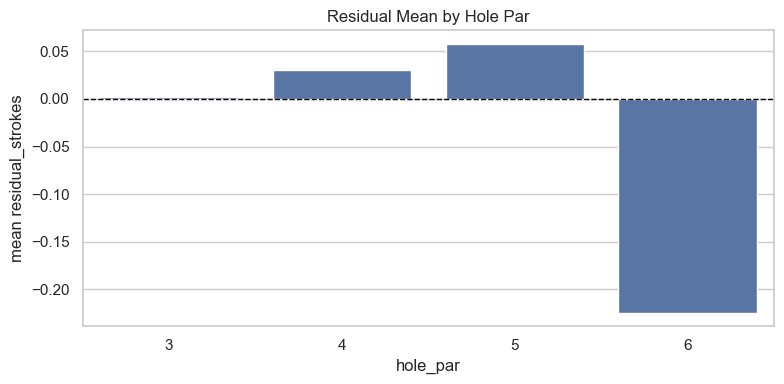

In [21]:
# -----------------------------------------------------------------------------
# Residual mean by hole par
# -----------------------------------------------------------------------------

plot_df = residuals_by_hole_par.copy().sort_values("hole_par")

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="hole_par", y="residual_mean")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Hole Par")
plt.xlabel("hole_par")
plt.ylabel("mean residual_strokes")
plt.tight_layout()
plt.show()


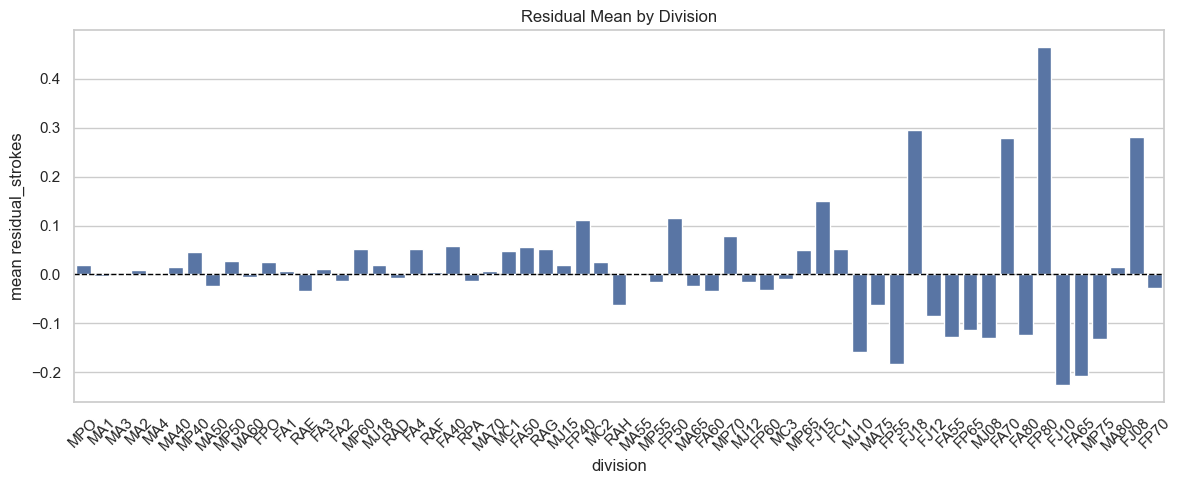

In [22]:
# -----------------------------------------------------------------------------
# Residual mean by division
# -----------------------------------------------------------------------------

plot_df = residuals_by_division.copy().sort_values("rows", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="division", y="residual_mean")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Division")
plt.xlabel("division")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


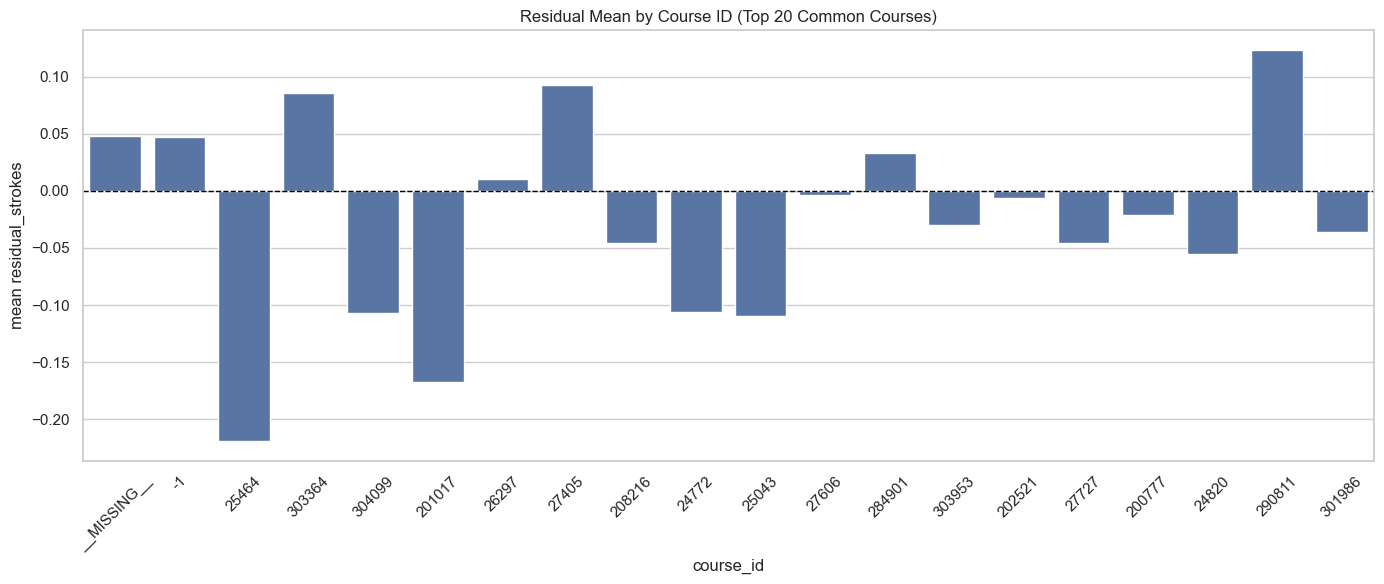

In [23]:
# -----------------------------------------------------------------------------
# Residual mean by common course
# -----------------------------------------------------------------------------

plot_df = residuals_by_course_id_common.copy()
plot_df = plot_df.sort_values("rows", ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="course_id", y="residual_mean")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Course ID (Top 20 Common Courses)")
plt.xlabel("course_id")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


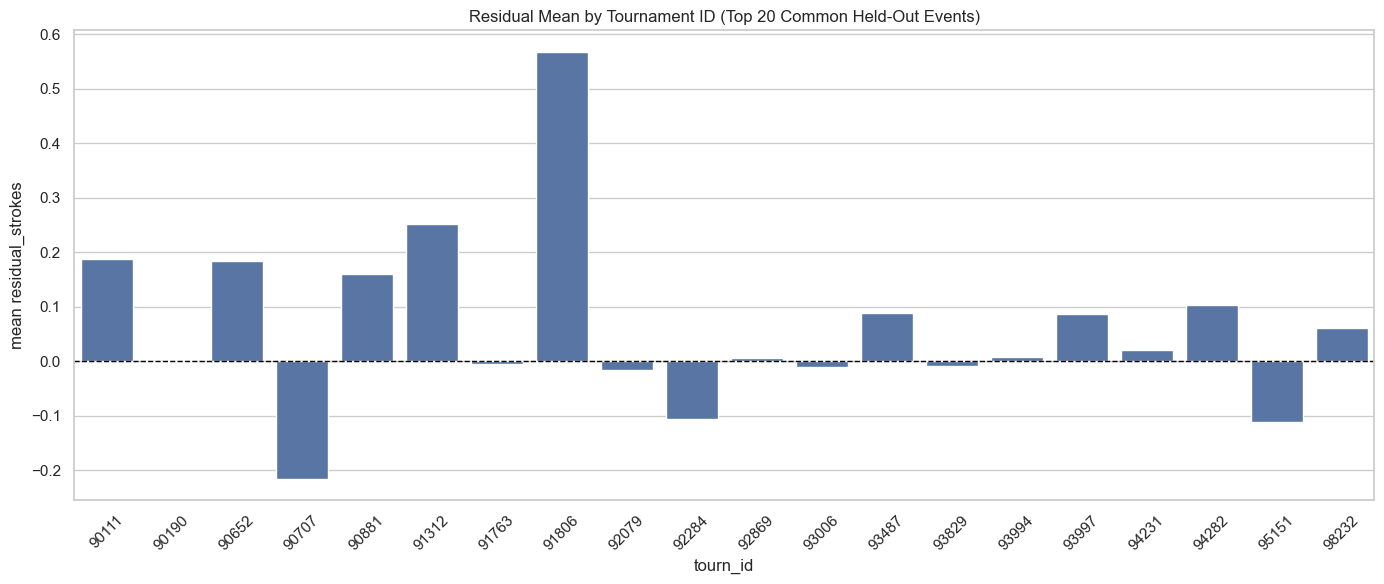

In [24]:
# -----------------------------------------------------------------------------
# Residual mean by tournament
# -----------------------------------------------------------------------------

plot_df = residuals_by_tourn_id.copy()
plot_df = plot_df.sort_values("rows", ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="tourn_id", y="residual_mean")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Tournament ID (Top 20 Common Held-Out Events)")
plt.xlabel("tourn_id")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


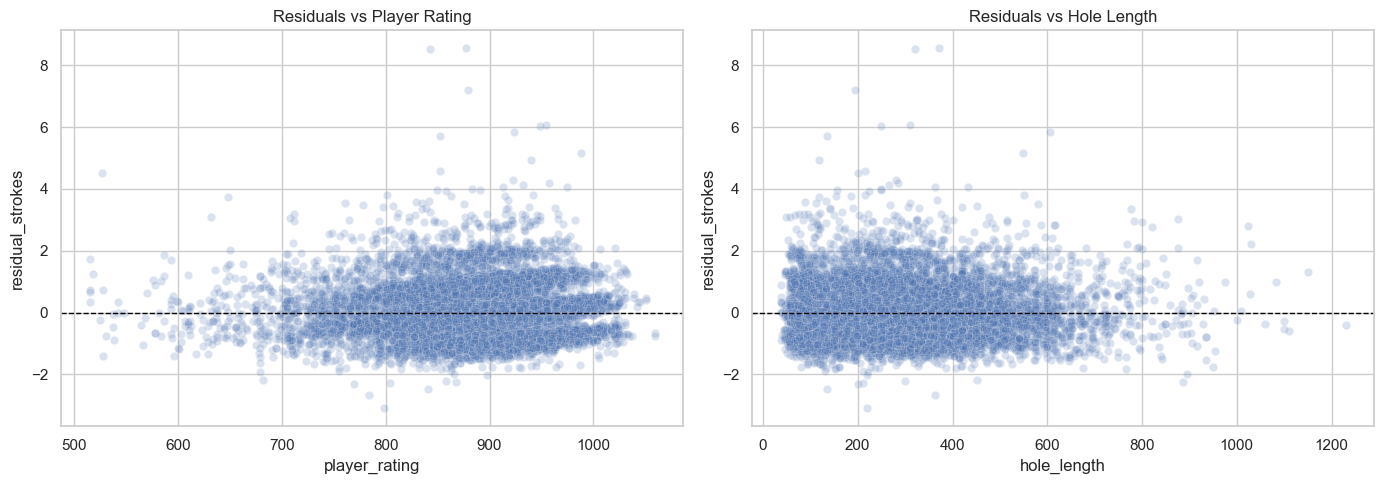

In [25]:
# -----------------------------------------------------------------------------
# Scatter views for continuous diagnostics
# -----------------------------------------------------------------------------

sample_df = winning_df.sample(min(15000, len(winning_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=sample_df,
    x="player_rating",
    y="residual_strokes",
    alpha=0.2,
    ax=axes[0],
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Player Rating")

sns.scatterplot(
    data=sample_df,
    x="hole_length",
    y="residual_strokes",
    alpha=0.2,
    ax=axes[1],
)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Hole Length")

plt.tight_layout()
plt.show()


In [26]:
# -----------------------------------------------------------------------------
# Export residual diagnostics
# -----------------------------------------------------------------------------

residuals_by_player_rating_bin.to_csv(OUTPUT_DIR / "winning_model_residuals_by_player_rating_bin.csv", index=False)
residuals_by_hole_length_bin.to_csv(OUTPUT_DIR / "winning_model_residuals_by_hole_length_bin.csv", index=False)
residuals_by_hole_par.to_csv(OUTPUT_DIR / "winning_model_residuals_by_hole_par.csv", index=False)
residuals_by_division.to_csv(OUTPUT_DIR / "winning_model_residuals_by_division.csv", index=False)
residuals_by_tourn_id.to_csv(OUTPUT_DIR / "winning_model_residuals_by_tourn_id.csv", index=False)
residuals_by_course_id_common.to_csv(OUTPUT_DIR / "winning_model_residuals_by_common_course_id.csv", index=False)
diagnostic_summary.to_csv(OUTPUT_DIR / "winning_model_residual_diagnostic_summary.csv", index=False)

print("Residual diagnostic exports written to:", OUTPUT_DIR)


Residual diagnostic exports written to: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports
